In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Setup successful!")

Setup successful!


In [7]:
df = pd.read_csv("C:/Users/chakr/OneDrive/Documents/example e commerce.csv", encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [9]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [11]:
df = df.dropna(subset=['CustomerID'])

In [12]:
df = df.drop_duplicates()

In [13]:
df = df[df['Quantity'] > 0]

In [14]:
df = df[df['UnitPrice'] > 0]

In [15]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [16]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [17]:
df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head()

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Name: TotalPrice, dtype: float64

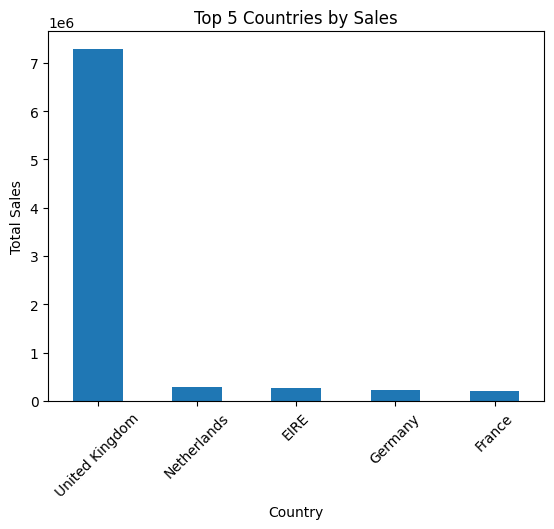

In [18]:
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head()

top_countries.plot(kind='bar')
plt.title("Top 5 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [19]:
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head()

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
Name: Quantity, dtype: int64

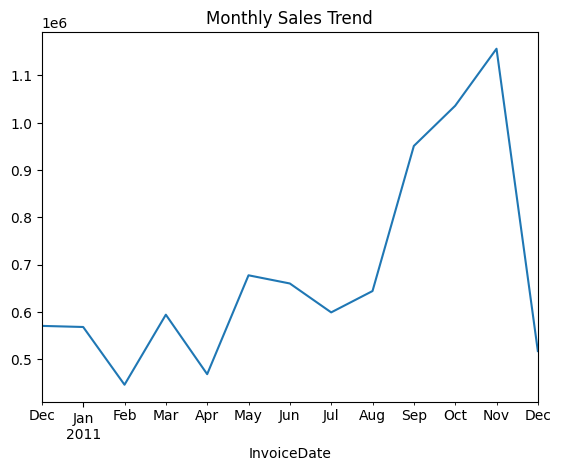

In [21]:
df.set_index('InvoiceDate')['TotalPrice'].resample('ME').sum().plot()
plt.title("Monthly Sales Trend")
plt.show()

In [24]:
df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(3)

Description
PAPER CRAFT , LITTLE BIRDIE          80995
MEDIUM CERAMIC TOP STORAGE JAR       77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS    54319
Name: Quantity, dtype: int64